In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('data/real_estate_raw.csv')

In [4]:
df.head()

,listing_id,property_type,country,city,neighborhood,surface_m2,num_rooms,num_bathrooms,floor,year_built,price,listing_date,condition,heating_type,parking,energy_rating
0,1665,studio,Germany,Berlin,SUBURBS,287.0,6.0,2.0,1.0,1984.0,230376,2023-03-12,Old,Electric,YES,G
1,1870,house,NaN,Naples,NaN,378.0,3.0,4.0,17.0,1973.0,1856023,2022-10-25,Old,electric,NaN,c
2,1415,Villa,France,Lyon,SUBURBS,277.0,8.0,3.0,5.0,1980.0,710838,06/02/2020,NaN,Central,1,D
3,1504,Villa,Netherlands,Amsterdam,Suburbs,245.0,2.0,4.0,14.0,1953.0,1869348,2019-01-16,NaN,Electric,yes,D
4,2333,house,Spain,Valencia,City Center,94.0,4.0,2.0,8.0,2005.0,1836672,2023-12-03,New,CENTRAL,NO,b


In [6]:
df.shape

(2060, 16)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     2060 non-null   int64  
 1   property_type  2060 non-null   str    
 2   country        1817 non-null   str    
 3   city           2060 non-null   str    
 4   neighborhood   1810 non-null   str    
 5   surface_m2     1878 non-null   float64
 6   num_rooms      1932 non-null   float64
 7   num_bathrooms  1947 non-null   float64
 8   floor          1944 non-null   float64
 9   year_built     1873 non-null   float64
 10  price          2060 non-null   str    
 11  listing_date   2060 non-null   str    
 12  condition      1649 non-null   str    
 13  heating_type   1813 non-null   str    
 14  parking        1806 non-null   str    
 15  energy_rating  1840 non-null   str    
dtypes: float64(5), int64(1), str(10)
memory usage: 257.6 KB


In [8]:
df.isnull().sum()

listing_id         0
property_type      0
country          243
city               0
neighborhood     250
surface_m2       182
num_rooms        128
num_bathrooms    113
floor            116
year_built       187
price              0
listing_date       0
condition        411
heating_type     247
parking          254
energy_rating    220
dtype: int64

In [9]:
df.columns

Index(['listing_id', 'property_type', 'country', 'city', 'neighborhood',
       'surface_m2', 'num_rooms', 'num_bathrooms', 'floor', 'year_built',
       'price', 'listing_date', 'condition', 'heating_type', 'parking',
       'energy_rating'],
      dtype='str')

In [10]:
df.describe()

,listing_id,surface_m2,num_rooms,num_bathrooms,floor,year_built
count,2060.000000,1878.000000,1932.000000,1947.000000,1944.000000,1873.000000
mean,1996.279612,415.017039,4.541408,2.463790,10.109053,1987.122264
std,577.614469,1400.342941,2.278134,1.112435,6.001324,20.897402
min,1000.000000,20.000000,1.000000,1.000000,0.000000,1950.000000
25%,1496.750000,118.000000,3.000000,1.000000,5.000000,1970.000000
50%,1993.500000,216.000000,5.000000,2.000000,10.000000,1987.000000
75%,2495.250000,314.000000,7.000000,3.000000,15.000000,2005.000000
max,2999.000000,9999.000000,8.000000,4.000000,20.000000,2023.000000


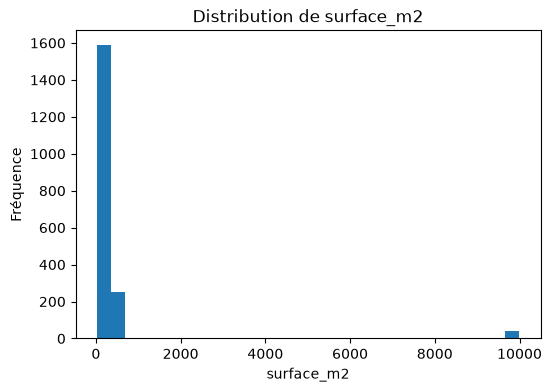

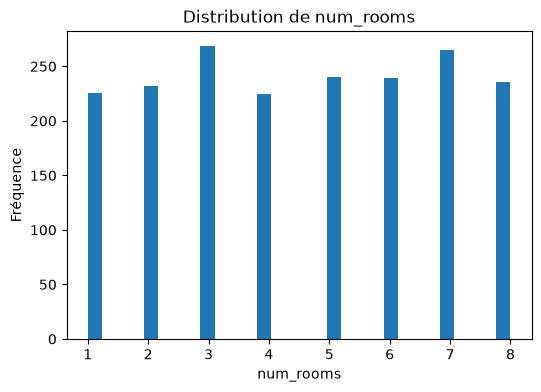

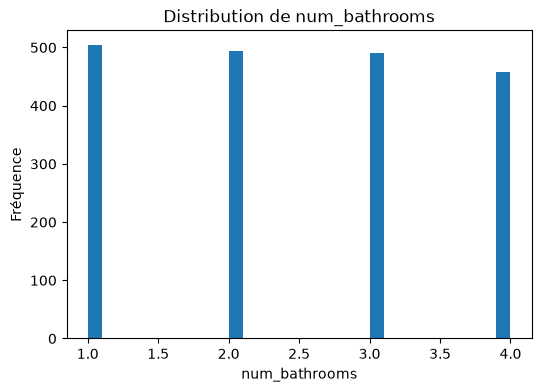

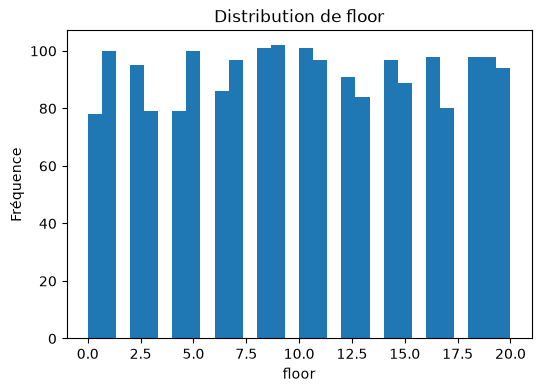

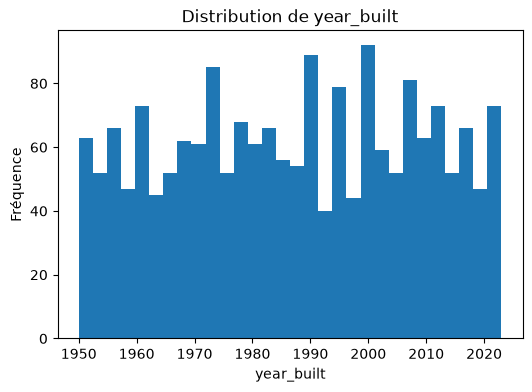

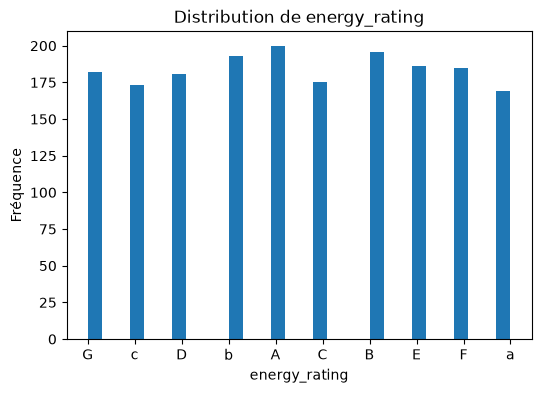

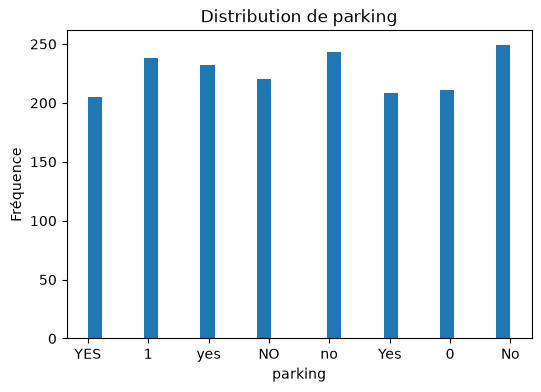

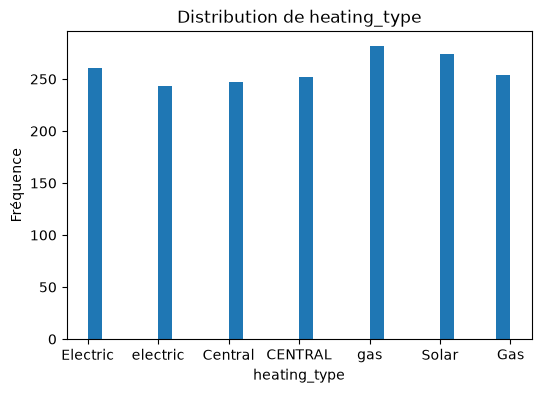

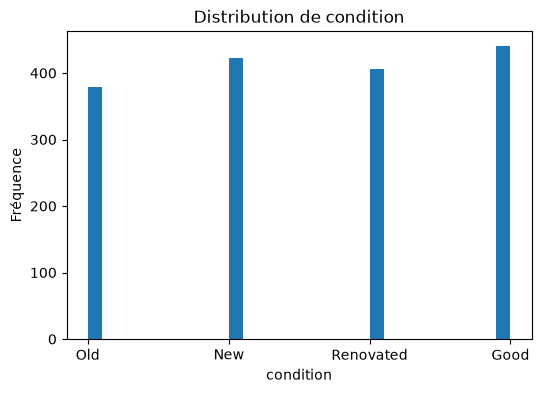

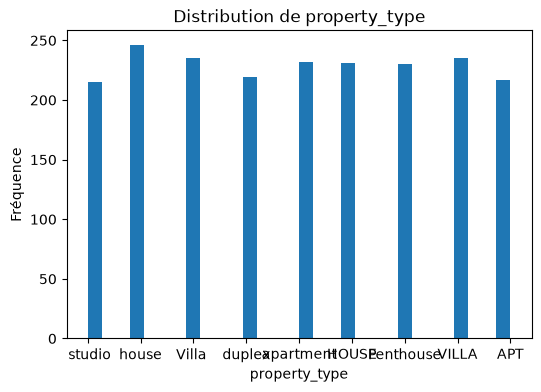

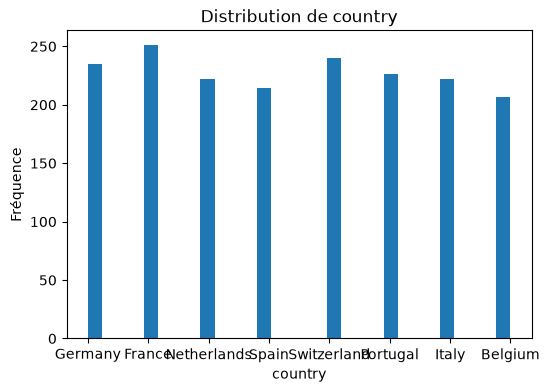

In [7]:
import matplotlib.pyplot as plt

cols = ["surface_m2", "num_rooms", "num_bathrooms", "floor", "year_built", "energy_rating", "parking", "heating_type", "condition", "property_type", "country"]

for col in cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [13]:
skewness = df[["surface_m2","num_rooms","num_bathrooms","floor","year_built"]].skew()

print(skewness)

surface_m2       6.662375
num_rooms       -0.017541
num_bathrooms    0.039633
floor           -0.008292
year_built      -0.046310
dtype: float64


In [6]:
df.duplicated

<bound method DataFrame.duplicated of       listing_id property_type      country       city neighborhood  \
0           1665        studio      Germany     Berlin      SUBURBS   
1           1870         house          NaN     Naples          NaN   
2           1415        Villa        France       Lyon      SUBURBS   
3           1504        Villa   Netherlands  Amsterdam      Suburbs   
4           2333         house        Spain   Valencia  City Center   
...          ...           ...          ...        ...          ...   
2055        2168         VILLA  Switzerland   Lausanne  Residential   
2056        1338        studio          NaN    Coimbra     Historic   
2057        1543        duplex          NaN    Leipzig      Suburbs   
2058        1110         VILLA          NaN  Frankfurt  City Center   
2059        2336     Penthouse  Switzerland      Basel     Historic   

      surface_m2  num_rooms  num_bathrooms  floor  year_built    price  \
0          287.0        6.0        